In [49]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn

In [50]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device

'cuda'

In [51]:
X = np.random.uniform(-10, 10, 100)

In [52]:
X = X.reshape(-1, 1)

In [53]:
X.shape

(100, 1)

In [54]:
Y = 3*X - 2 

In [55]:
Y = Y.reshape(-1, 1)

In [56]:
Y.shape

(100, 1)

In [57]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.capa = nn.Linear(1,1)

    def forward(self, x):
        y = self.capa(x)
        return y

In [58]:
model = SimpleNet().to(device)
print(model)

SimpleNet(
  (capa): Linear(in_features=1, out_features=1, bias=True)
)


In [59]:
X_tensor = torch.from_numpy(X).float().to(device)
Y_tensor = torch.from_numpy(Y).float().to(device)

In [60]:
result = model(X_tensor)

In [61]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [62]:
for epoch in range(600):
    y_pred = model(X_tensor)
    loss = criterion(y_pred, Y_tensor)

    # Reset the gradients of model parameters
    optimizer.zero_grad()
    # Backpropagation the prediction loss
    loss.backward()
    # We call to adjust the parameters
    optimizer.step()

    if (epoch + 1) % 100  == 0:
        print(f"Loss {loss.item():.5f}")

Loss 0.02844
Loss 0.00051
Loss 0.00001
Loss 0.00000
Loss 0.00000
Loss 0.00000


In [63]:
value_test = torch.tensor([[4.0]]).to(device)

In [64]:
value_test

tensor([[4.]], device='cuda:0')

In [65]:
model(value_test).item()

10.000006675720215

In [66]:
Y_pred_tensor = model(X_tensor)

In [67]:
X_np = X_tensor.cpu().numpy()
Y_np = Y_tensor.cpu().numpy()
Y_pred_np = Y_pred_tensor.detach().cpu().numpy()

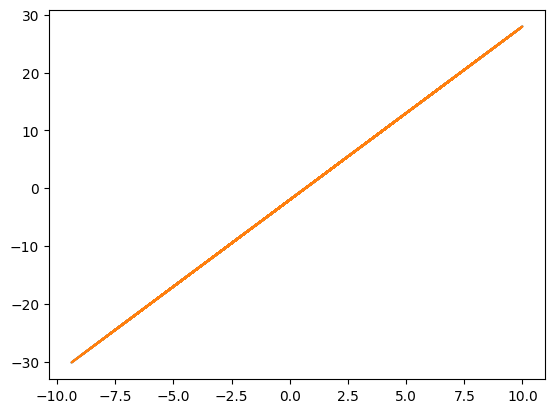

In [68]:
plt.plot(X_np, Y_np)
plt.plot(X_np, Y_pred_np)
plt.show()